# Модель Бернулли

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from typing import List, Tuple

import sys
import os

sys.path.append(os.path.abspath('/Users/v.makshanchikov/Documents/Python Proj/ВКР Магистратура/stochastic_models/poisson'))
from bernoulli_model import compute_bernoulli_parameters, test_bernoulli_assumptions, visualize_bernoulli_process

def extract_event_frames(counts: np.ndarray, threshold: int = 3) -> np.ndarray:
    """
    Извлекает номера кадров, в которых произошло изменение количества людей.
    
    Parameters:
    -----------
    counts : np.ndarray
        Массив количества людей на каждом кадре.
    threshold : int
        Минимальное абсолютное изменение, чтобы считаться событием.
        Если threshold == 0, учитываются любые изменения.
    
    Returns:
    --------
    event_frames : np.ndarray
        Отсортированный массив номеров кадров с событиями.
    """
    events = []
    for i in range(1, len(counts)):
        diff = counts[i] - counts[i-1]
        if abs(diff) >= threshold:
            events.append(i)   # кадр, где произошло изменение
    return np.array(events)


BASELINE (original.npy)
p = 0.375500 ± 0.010828
Событий: 751 из 2000 кадров
Средний интервал: 2.66 кадров
Стационарность p-value: 0.0396

=== Проверка свойств процесса Бернулли для Original (без шума) ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=27.8853, p-value=0.0019
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.8673
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0805
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 2.0020
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


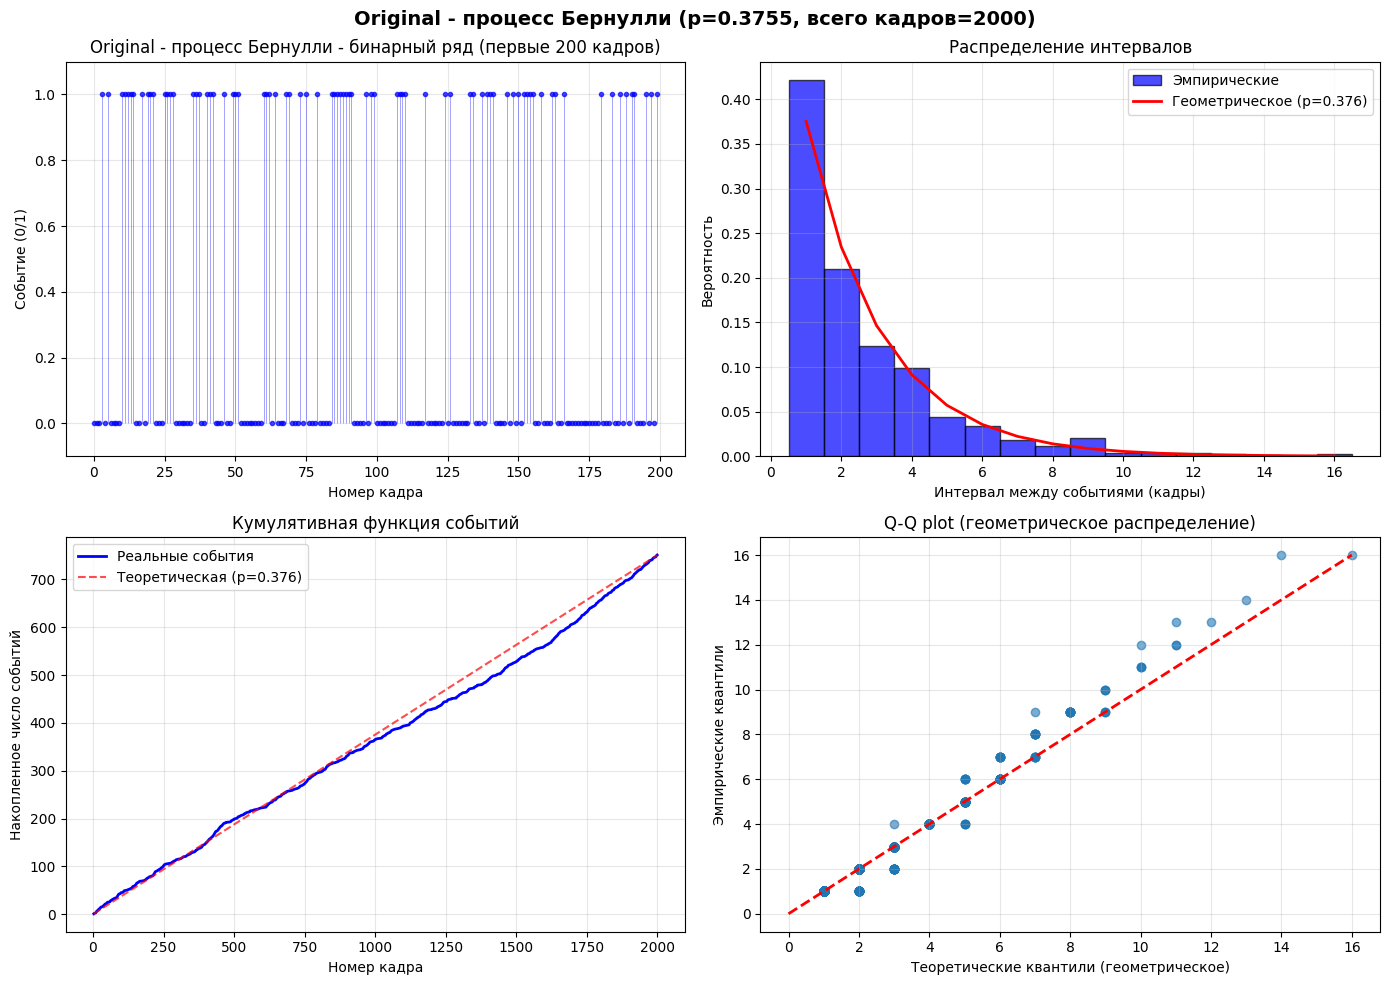

In [ ]:
# Укажите путь к папке с .npy файлами
results_dir = Path("/Users/v.makshanchikov/Documents/Python Proj/ВКР Магистратура/inferense_datasets/groundingdino_results_parr")

# Загружаем оригинальные данные (без шума)
original_counts = np.load(results_dir / "original.npy")
total_frames = len(original_counts)
EVENT_THRESHOLD = 3

# Базовые события для original
original_event_frames = extract_event_frames(original_counts, threshold=EVENT_THRESHOLD)
original_params = compute_bernoulli_parameters(original_event_frames, total_frames)
baseline_p = original_params["p"]

print("=" * 70)
print("BASELINE (original.npy)")
print("=" * 70)
print(f"p = {baseline_p:.6f} ± {original_params['p_std']:.6f}")
print(f"Событий: {original_params['n_events']} из {total_frames} кадров")
print(f"Средний интервал: {original_params['mean_interval_frames']:.2f} кадров")
if 'stationarity_pvalue' in original_params:
    print(f"Стационарность p-value: {original_params['stationarity_pvalue']:.4f}")
test_bernoulli_assumptions(original_event_frames, total_frames, title="Original (без шума)")
visualize_bernoulli_process(original_event_frames, total_frames, title="Original - процесс Бернулли")

In [24]:
# Определяем типы шумов и регулярные выражения для извлечения параметров
noise_types = {
    "gaussian": {"pattern": r"gaussian_var_([0-9.]+)\.npy", "param_name": "variance"},
    "poisson":  {"pattern": r"poisson_scale_([0-9.]+)\.npy", "param_name": "scale"},
    "salt_pepper": {"pattern": r"salt_pepper_prob_([0-9.]+)\.npy", "param_name": "probability"},
    "speckle":  {"pattern": r"speckle_scale_([0-9.]+)\.npy", "param_name": "scale"}
}

# Словари для хранения результатов
p_estimates = {nt: [] for nt in noise_types}
assumptions_summary = {nt: [] for nt in noise_types}  # для сводной таблицы

for noise_name, info in noise_types.items():
    pattern = info["pattern"]
    files = list(results_dir.glob(f"{noise_name}_*.npy"))
    print(f"\n{'='*70}\nОбработка {noise_name.upper()} шума\n{'='*70}")
    
    for f in files:
        match = re.search(pattern, f.name)
        if not match:
            continue
        param = float(match.group(1))
        counts = np.load(f)
        if len(counts) != total_frames:
            print(f"Warning: {f.name} has length {len(counts)} != {total_frames}")
            continue
        
        event_frames = extract_event_frames(counts, threshold=EVENT_THRESHOLD)
        if len(event_frames) >= 2:
            params = compute_bernoulli_parameters(event_frames, total_frames, check_stationarity=False)
            p_estimates[noise_name].append({
                "param": param,
                "p": params["p"],
                "p_std": params["p_std"],
                "n_events": params["n_events"],
                "cv": params["cv"]
            })
            
            # Собираем данные для таблицы проверок
            intervals = np.diff(event_frames)
            if len(intervals) > 5:
                # Хи-квадрат тест (геометрическое распределение)
                observed_counts = np.bincount(intervals)
                max_int = max(intervals)
                theo_probs = stats.geom.pmf(np.arange(1, max_int+1), params["p"])
                theo_probs /= theo_probs.sum()
                expected = theo_probs * len(intervals)
                # Объединение категорий
                merged_obs, merged_exp = [], []
                curr_obs, curr_exp = 0, 0
                for i in range(len(theo_probs)):
                    curr_obs += observed_counts[i+1] if i+1 < len(observed_counts) else 0
                    curr_exp += expected[i]
                    if curr_exp >= 5 or i == len(theo_probs)-1:
                        if curr_exp > 0:
                            merged_obs.append(curr_obs)
                            merged_exp.append(curr_exp)
                        curr_obs, curr_exp = 0, 0
                chi2_p = stats.chisquare(merged_obs, merged_exp).pvalue if len(merged_obs) > 1 else np.nan
            else:
                chi2_p = np.nan
            
            autocorr = np.corrcoef(intervals[:-1], intervals[1:])[0,1] if len(intervals) > 10 else np.nan
            
            assumptions_summary[noise_name].append({
                "param": param,
                "p": params["p"],
                "chi2_pvalue": chi2_p,
                "cv": params["cv"],
                "autocorr": autocorr,
                "n_events": params["n_events"]
            })
        else:
            # Мало событий – модель неприменима
            p_estimates[noise_name].append({
                "param": param,
                "p": np.nan,
                "p_std": np.nan,
                "n_events": len(event_frames),
                "cv": np.nan
            })
            assumptions_summary[noise_name].append({
                "param": param,
                "p": np.nan,
                "chi2_pvalue": np.nan,
                "cv": np.nan,
                "autocorr": np.nan,
                "n_events": len(event_frames)
            })
    
    # Сортируем по параметру
    p_estimates[noise_name].sort(key=lambda x: x["param"])
    assumptions_summary[noise_name].sort(key=lambda x: x["param"])



Обработка GAUSSIAN шума

Обработка POISSON шума

Обработка SALT_PEPPER шума

Обработка SPECKLE шума


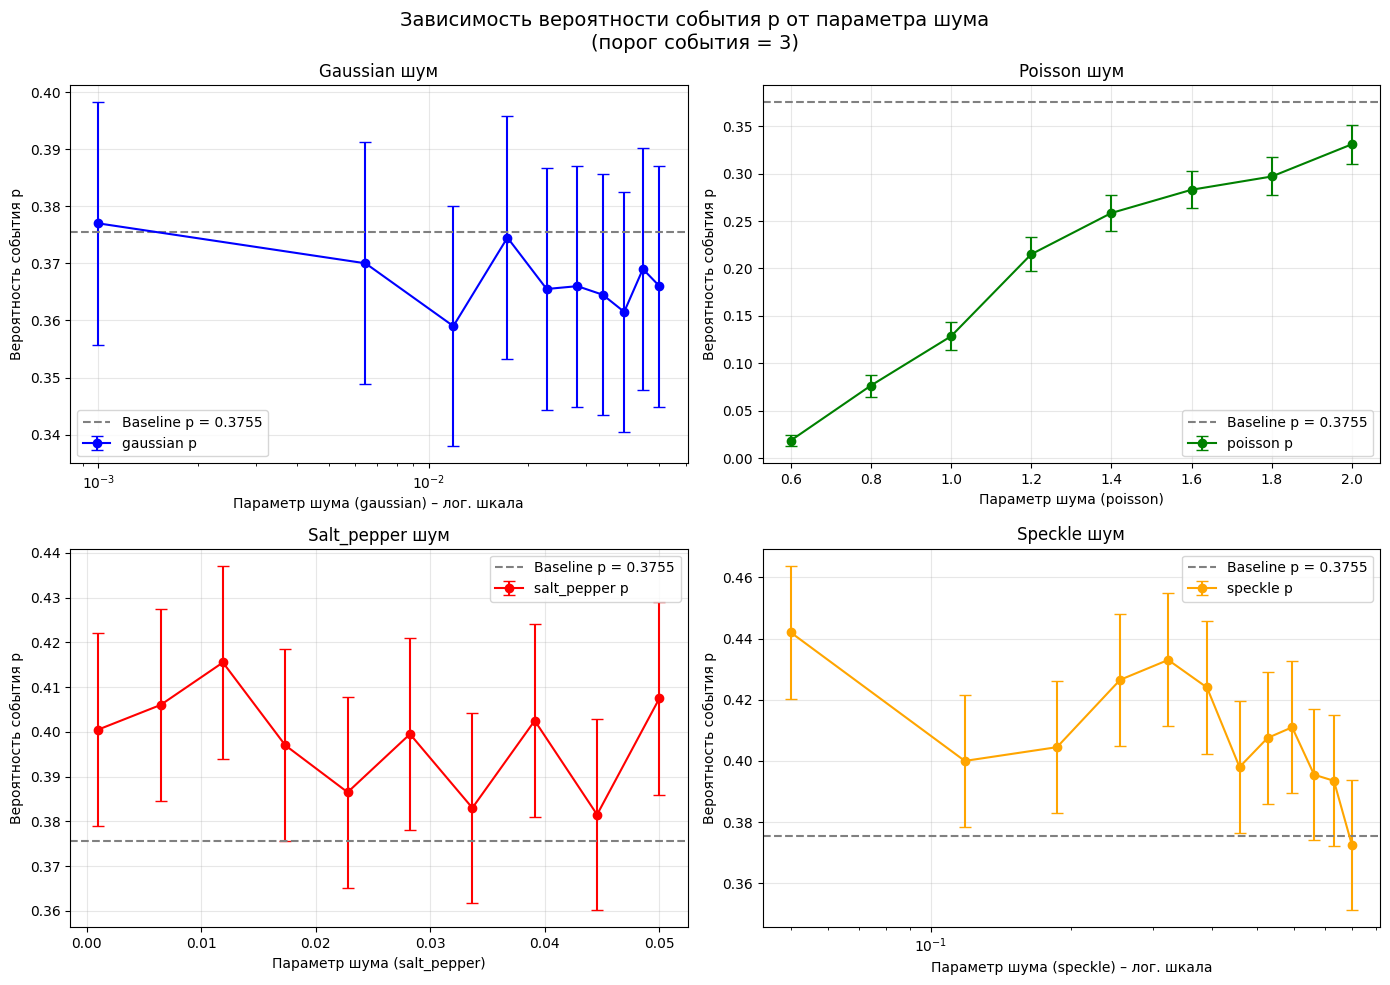

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Зависимость вероятности события p от параметра шума\n(порог события = {EVENT_THRESHOLD})", fontsize=14)

colors = {"gaussian": "blue", "poisson": "green", "salt_pepper": "red", "speckle": "orange"}

for ax, (noise_name, data) in zip(axes.flatten(), p_estimates.items()):
    if not data:
        ax.set_title(f"{noise_name.capitalize()} – нет данных")
        continue
    params = [d["param"] for d in data]
    p_vals = [d["p"] for d in data]
    p_stds = [d["p_std"] if not np.isnan(d["p_std"]) else 0 for d in data]
    
    mask = ~np.isnan(p_vals)
    if mask.sum() == 0:
        ax.set_title(f"{noise_name.capitalize()} – недостаточно событий")
        continue
    params_m = np.array(params)[mask]
    p_vals_m = np.array(p_vals)[mask]
    p_stds_m = np.array(p_stds)[mask]
    
    ax.errorbar(params_m, p_vals_m, yerr=1.96 * p_stds_m, fmt='o-', capsize=4,
                color=colors.get(noise_name, "black"), label=f"{noise_name} p")
    ax.axhline(y=baseline_p, color='gray', linestyle='--', label=f'Baseline p = {baseline_p:.4f}')
    ax.set_xlabel(f"Параметр шума ({noise_name})")
    ax.set_ylabel("Вероятность события p")
    ax.set_title(f"{noise_name.capitalize()} шум")
    ax.grid(True, alpha=0.3)
    ax.legend()
    if noise_name in ["gaussian", "speckle"] and len(params_m) > 1 and max(params_m)/min(params_m) > 10:
        ax.set_xscale('log')
        ax.set_xlabel(f"Параметр шума ({noise_name}) – лог. шкала")

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "=" * 70)
print("СВОДНАЯ ТАБЛИЦА ПРОВЕРКИ ПРИМЕНИМОСТИ МОДЕЛИ БЕРНУЛЛИ")
print("=" * 70)

for noise_name, data in assumptions_summary.items():
    df = pd.DataFrame(data)
    # Округлим для читаемости
    for col in ["p", "cv", "autocorr", "chi2_pvalue"]:
        if col in df.columns:
            df[col] = df[col].round(4)
    print(f"\n{noise_name.upper()}:")
    print(df.to_string(index=False))


СВОДНАЯ ТАБЛИЦА ПРОВЕРКИ ПРИМЕНИМОСТИ МОДЕЛИ БЕРНУЛЛИ

GAUSSIAN:
   param      p  chi2_pvalue     cv  autocorr  n_events
0.001000 0.3770       0.0372 0.8407    0.0991       754
0.006444 0.3700       0.0520 0.8317    0.0505       740
0.011889 0.3590       0.4299 0.8377    0.0423       718
0.017333 0.3745       0.1716 0.8526    0.1150       749
0.022778 0.3655       0.5169 0.8387    0.0647       731
0.028222 0.3660       0.0571 0.8689    0.0563       732
0.033667 0.3645       0.0480 0.8509    0.0493       729
0.039111 0.3615       0.0097 0.8923    0.0374       723
0.044556 0.3690       0.0152 0.8391    0.0335       738
0.050000 0.3660       0.0468 0.8628    0.0766       732

POISSON:
 param      p  chi2_pvalue     cv  autocorr  n_events
   0.2    NaN          NaN    NaN       NaN         0
   0.4    NaN          NaN    NaN       NaN         0
   0.6 0.0185       0.0000 1.4492   -0.0735        37
   0.8 0.0765       0.0000 1.4900   -0.0973       153
   1.0 0.1285       0.0000 1.2208   -0


=== Проверка свойств процесса Бернулли для GAUSSIAN шум, параметр=0.001000 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=19.2516, p-value=0.0372
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.8407
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0991
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 1.8715
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


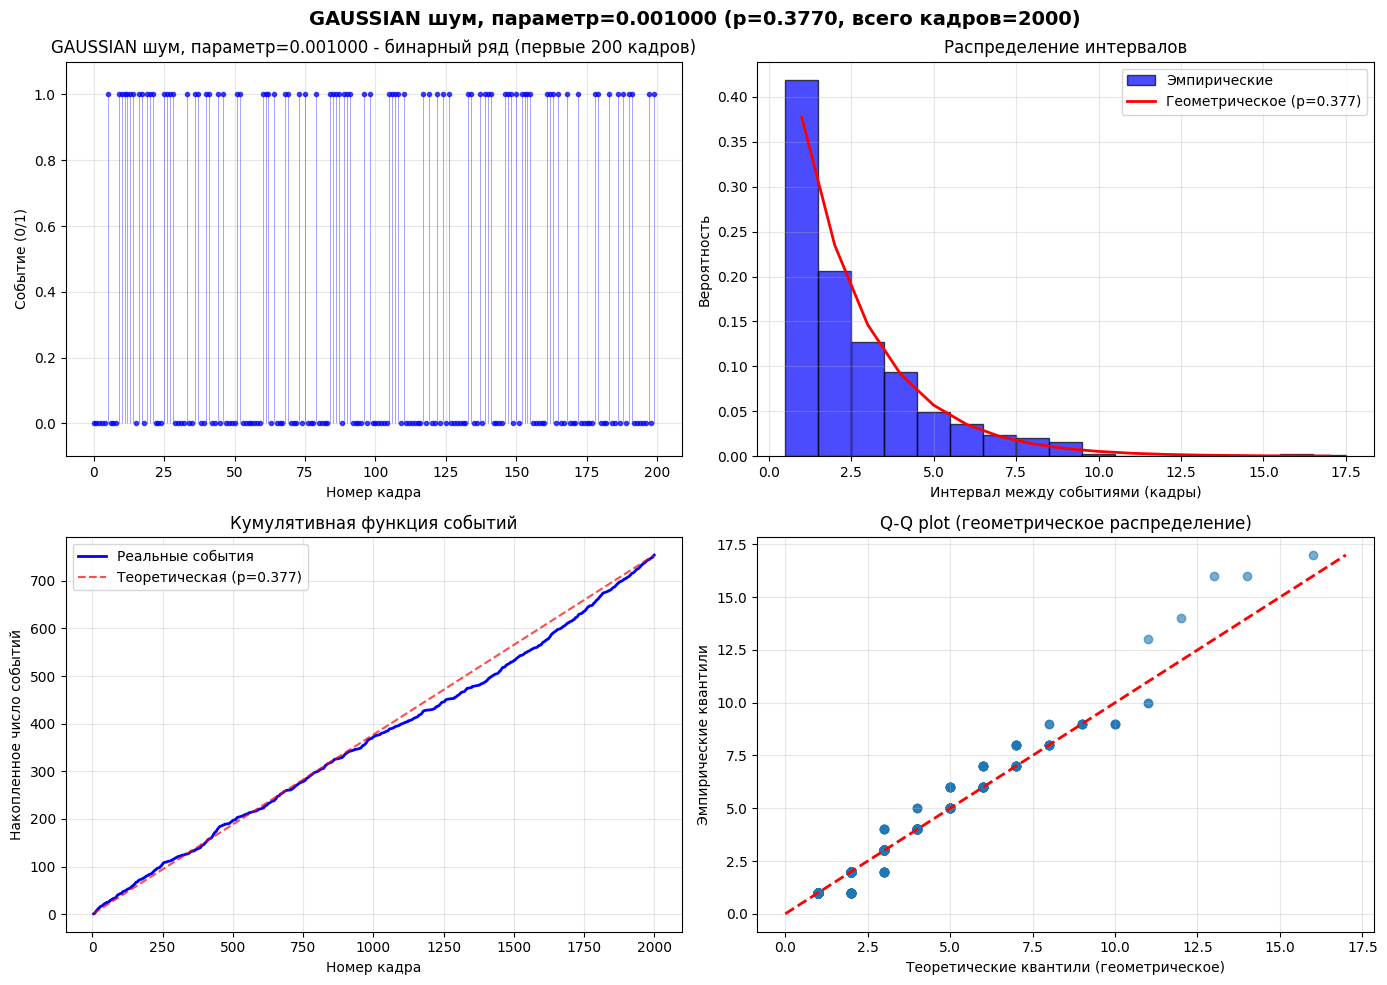


=== Проверка свойств процесса Бернулли для GAUSSIAN шум, параметр=0.028222 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=17.8773, p-value=0.0571
    ✓ Интервалы соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.8689
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0563
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 2.0596
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


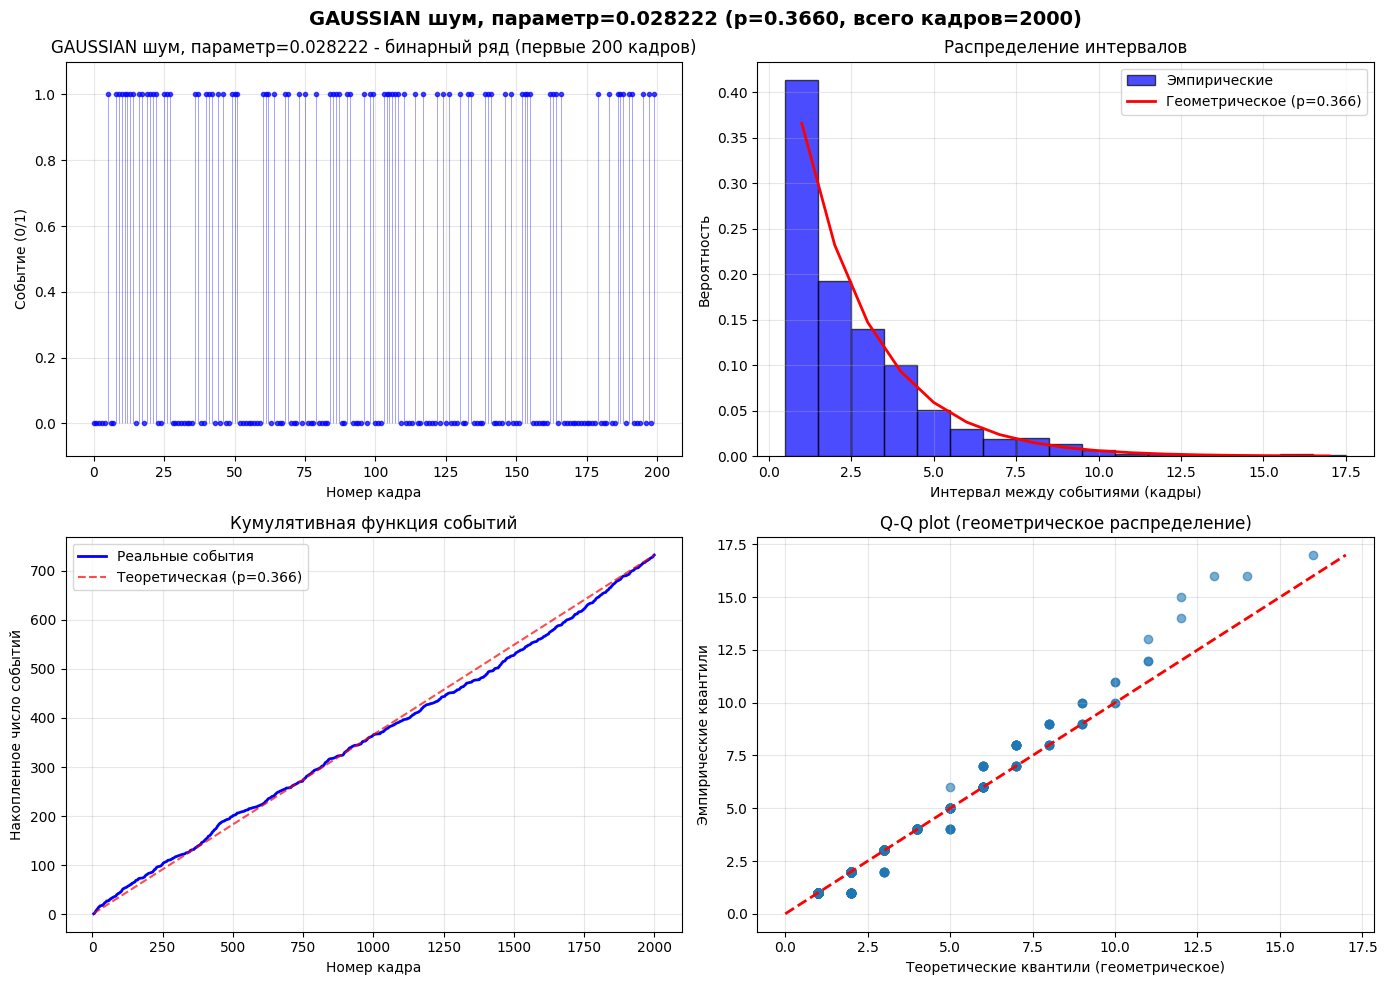


=== Проверка свойств процесса Бернулли для GAUSSIAN шум, параметр=0.050000 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=18.5177, p-value=0.0468
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.8628
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0766
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 2.0305
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


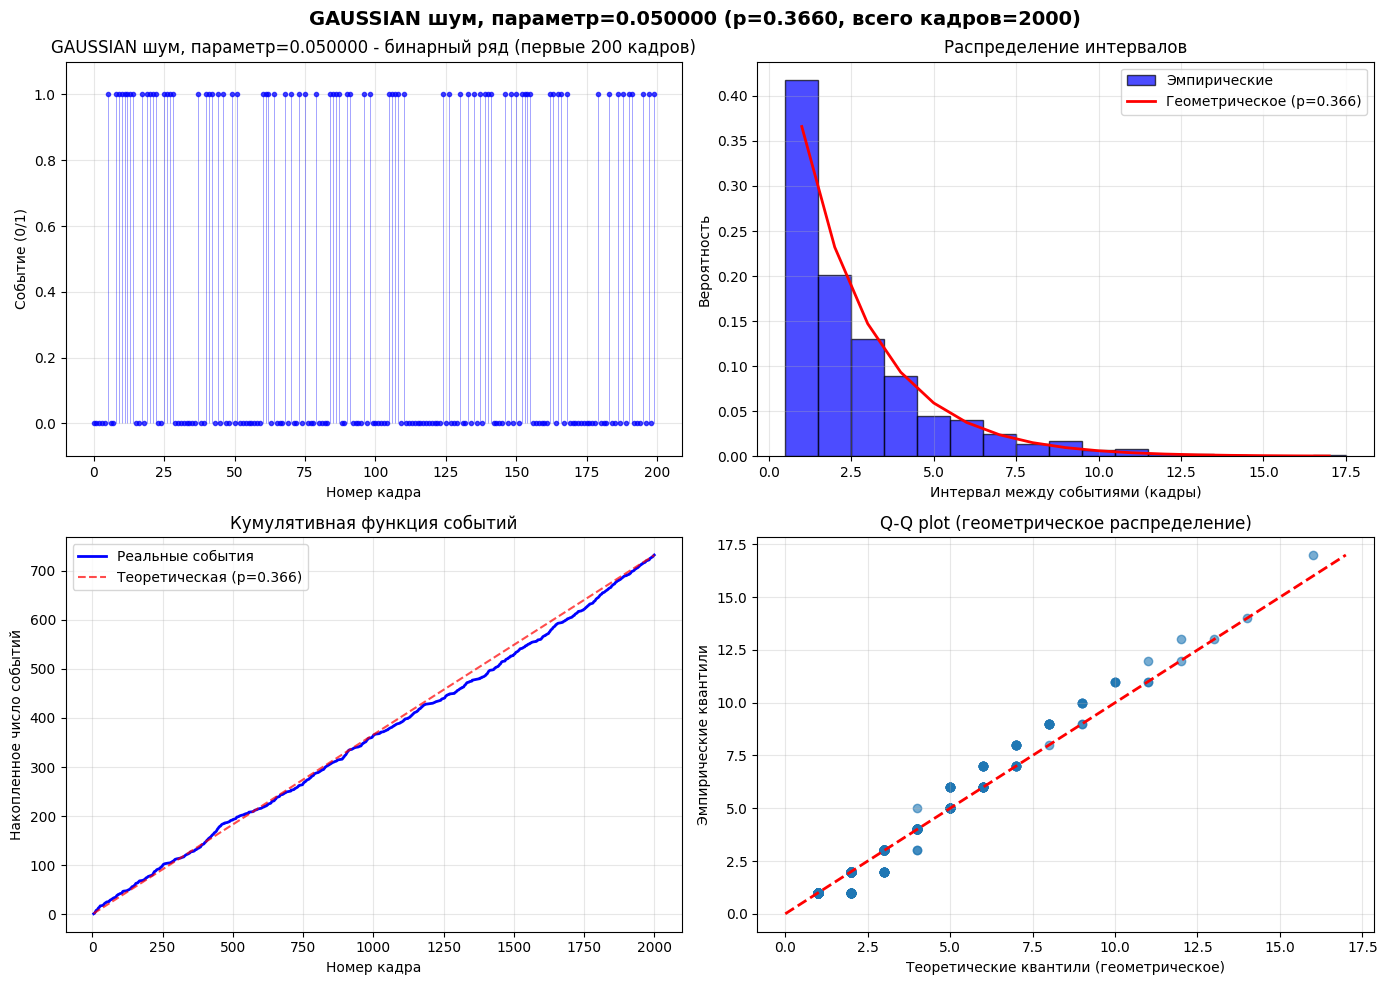


=== Проверка свойств процесса Бернулли для POISSON шум, параметр=0.600000 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=54.2972, p-value=0.0000
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 1.4492
    ⚠️ CV > 1.2 (сверхдисперсия, события кластеризуются)

  Автокорреляция интервалов: -0.0735
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 110.9004
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


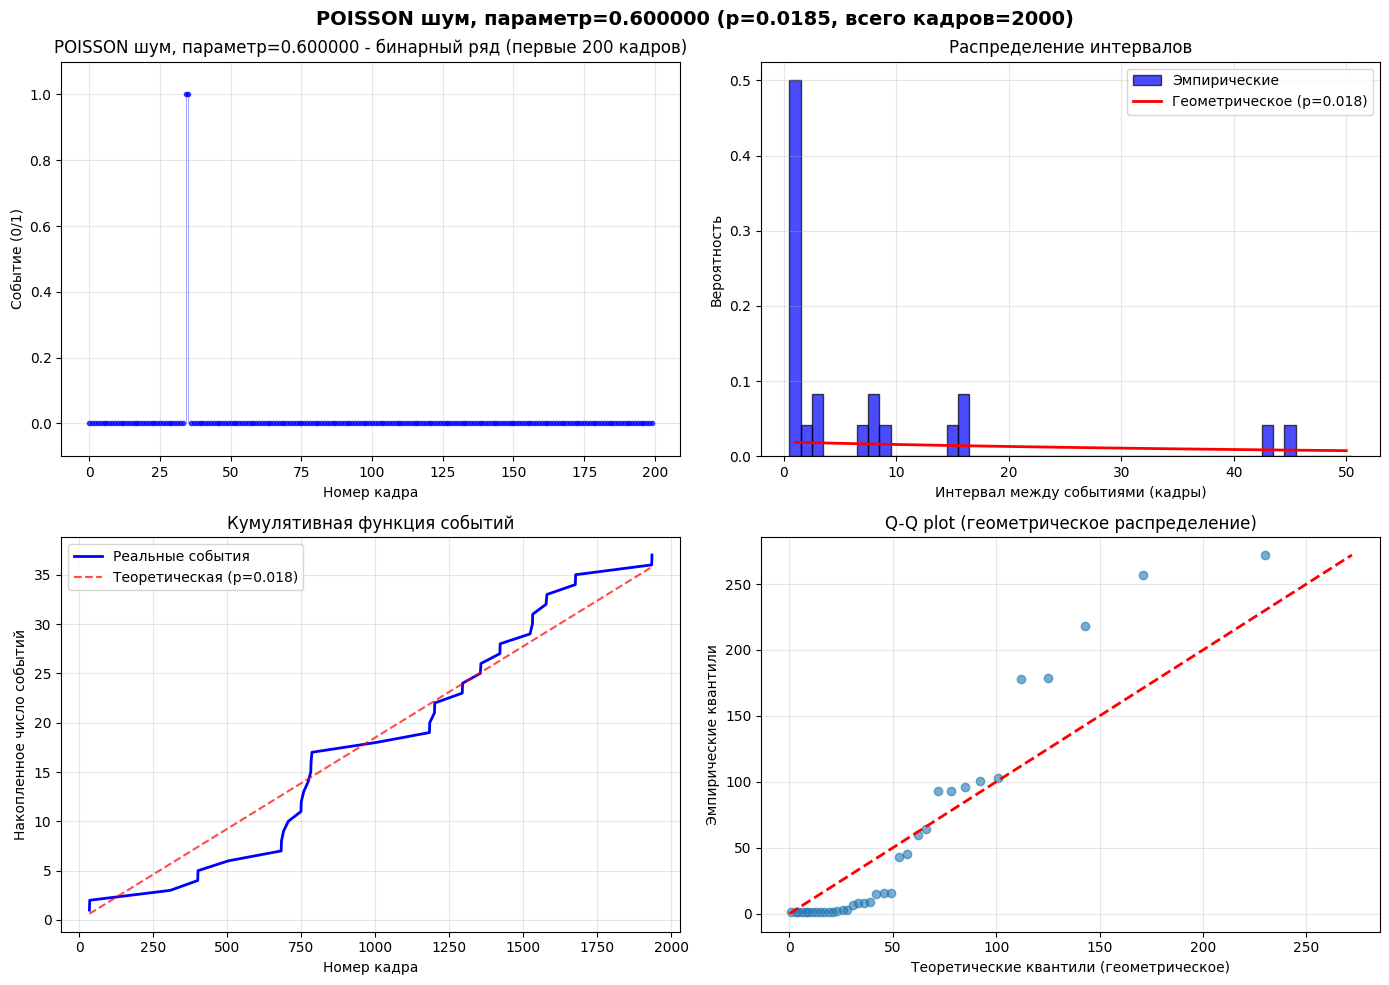


=== Проверка свойств процесса Бернулли для POISSON шум, параметр=1.400000 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=56.7782, p-value=0.0000
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 1.0268
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0040
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 4.0516
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


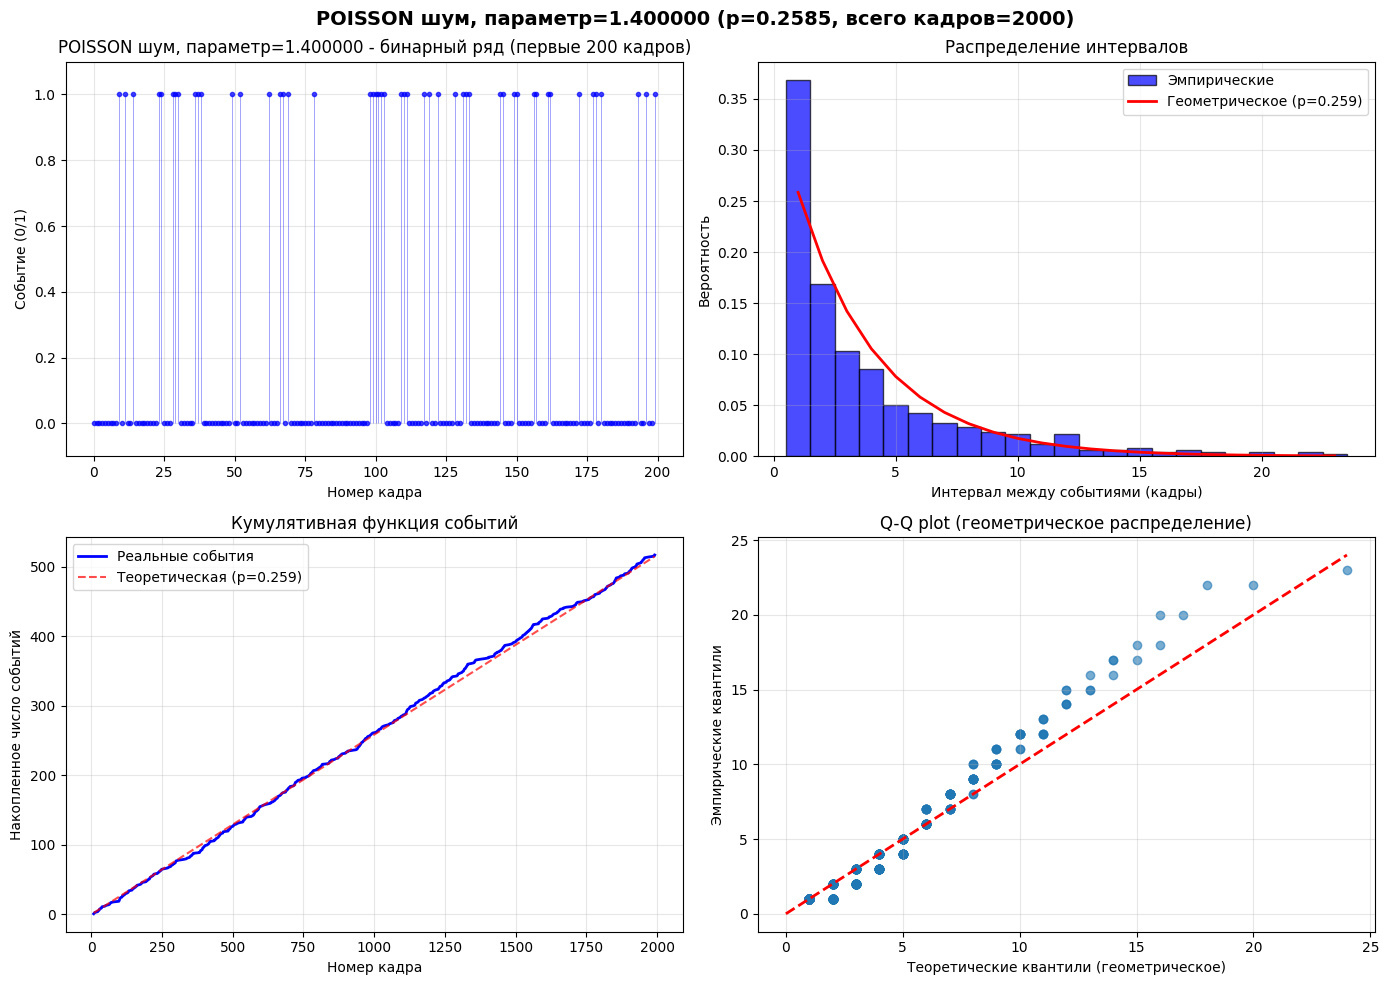


=== Проверка свойств процесса Бернулли для POISSON шум, параметр=2.000000 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=33.4269, p-value=0.0004
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.9247
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0380
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 2.5767
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


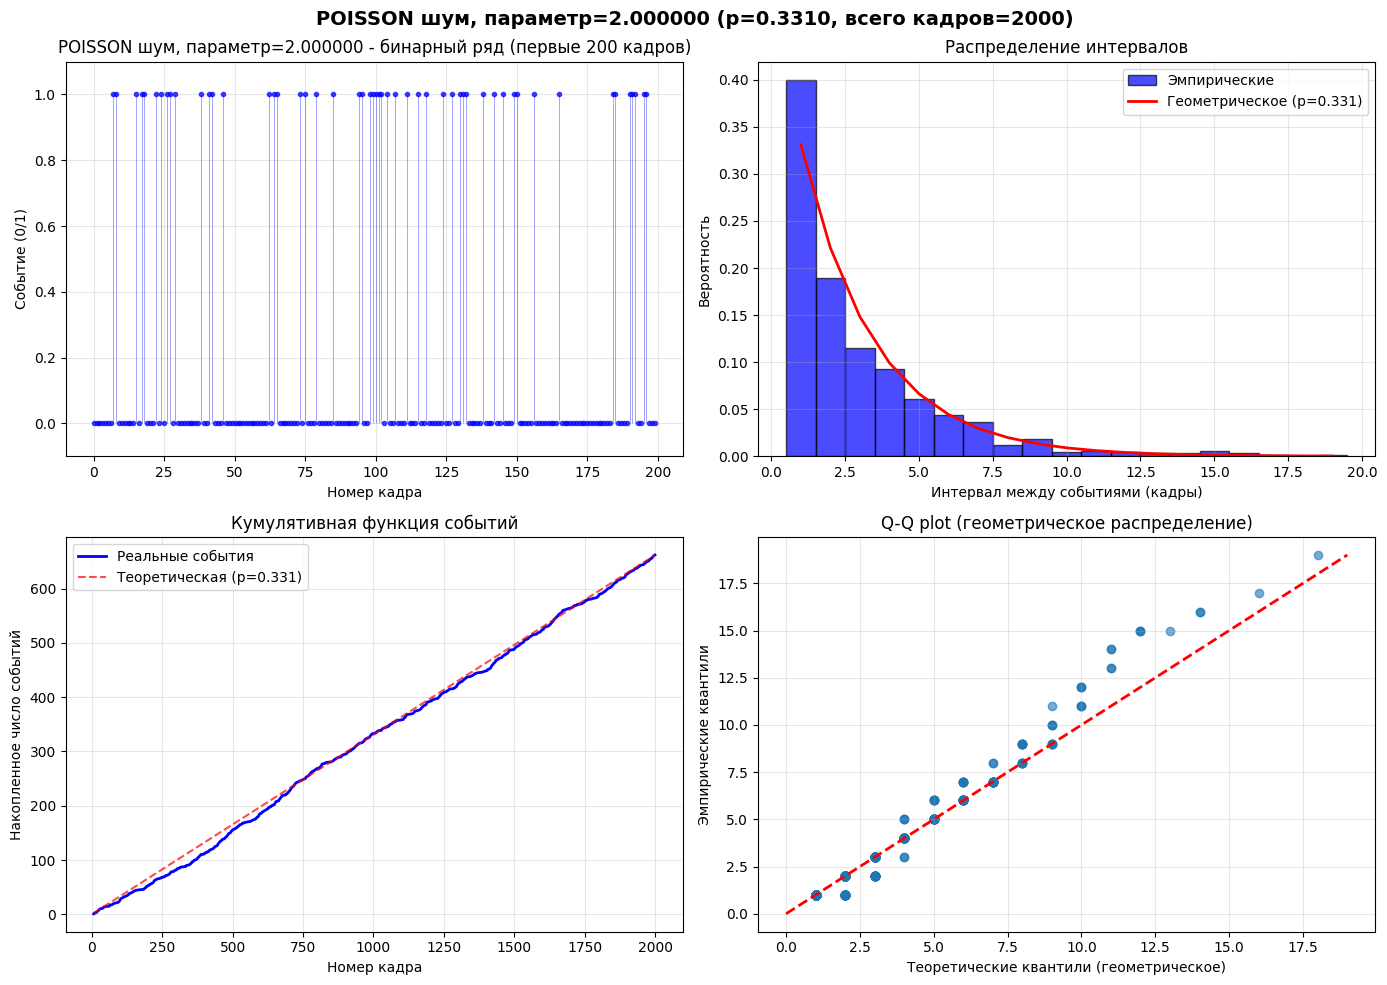


=== Проверка свойств процесса Бернулли для SALT_PEPPER шум, параметр=0.001000 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=28.5265, p-value=0.0015
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.8630
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0048
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 1.8565
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


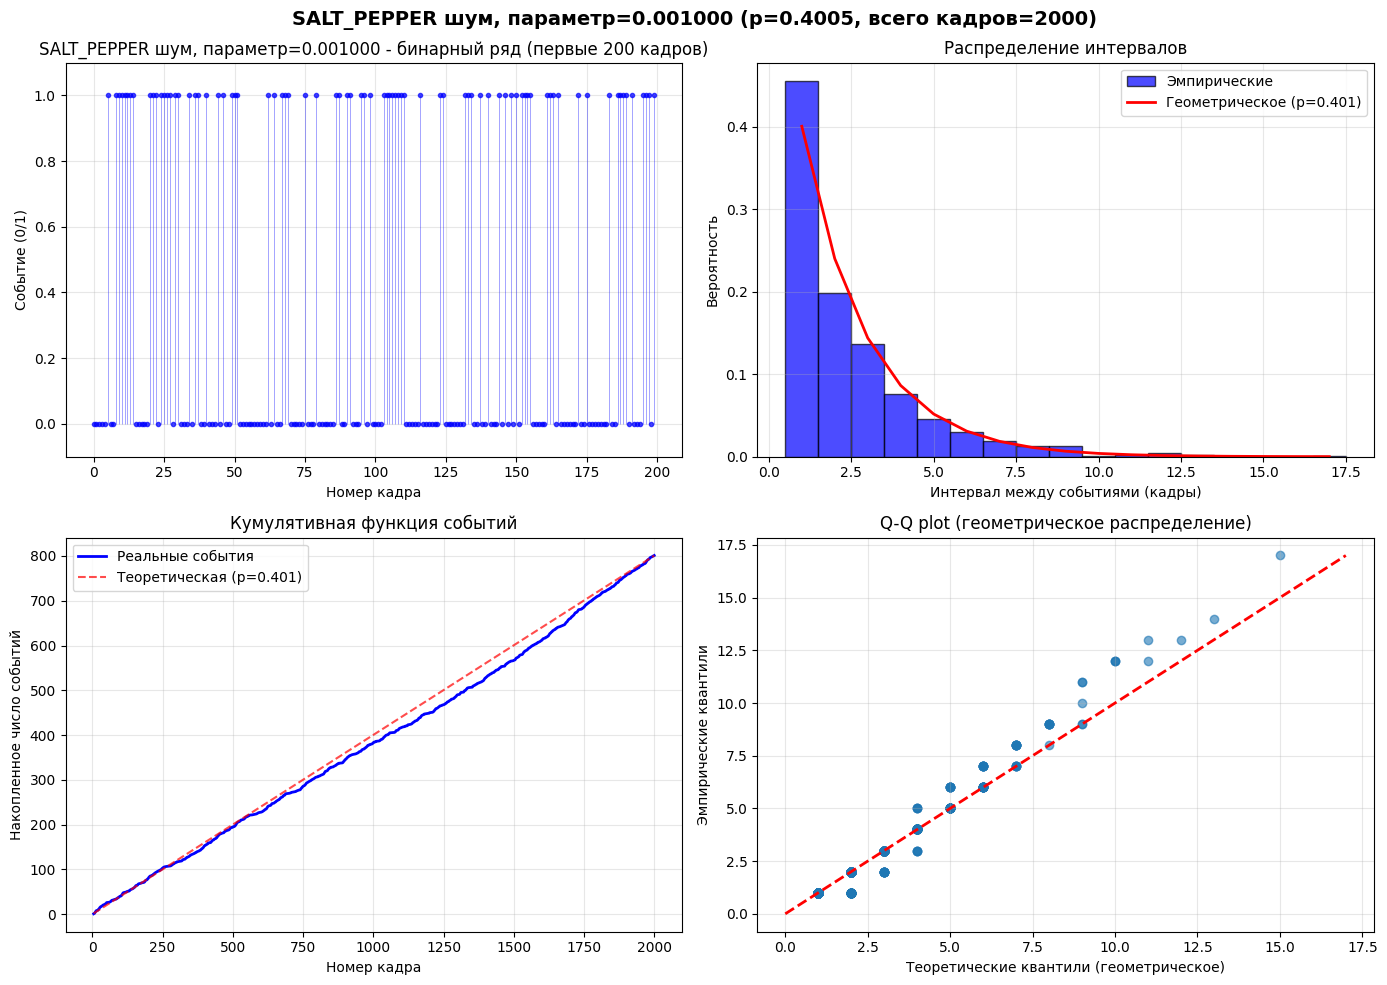


=== Проверка свойств процесса Бернулли для SALT_PEPPER шум, параметр=0.028222 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=19.0904, p-value=0.0391
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.8406
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0171
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 1.7673
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


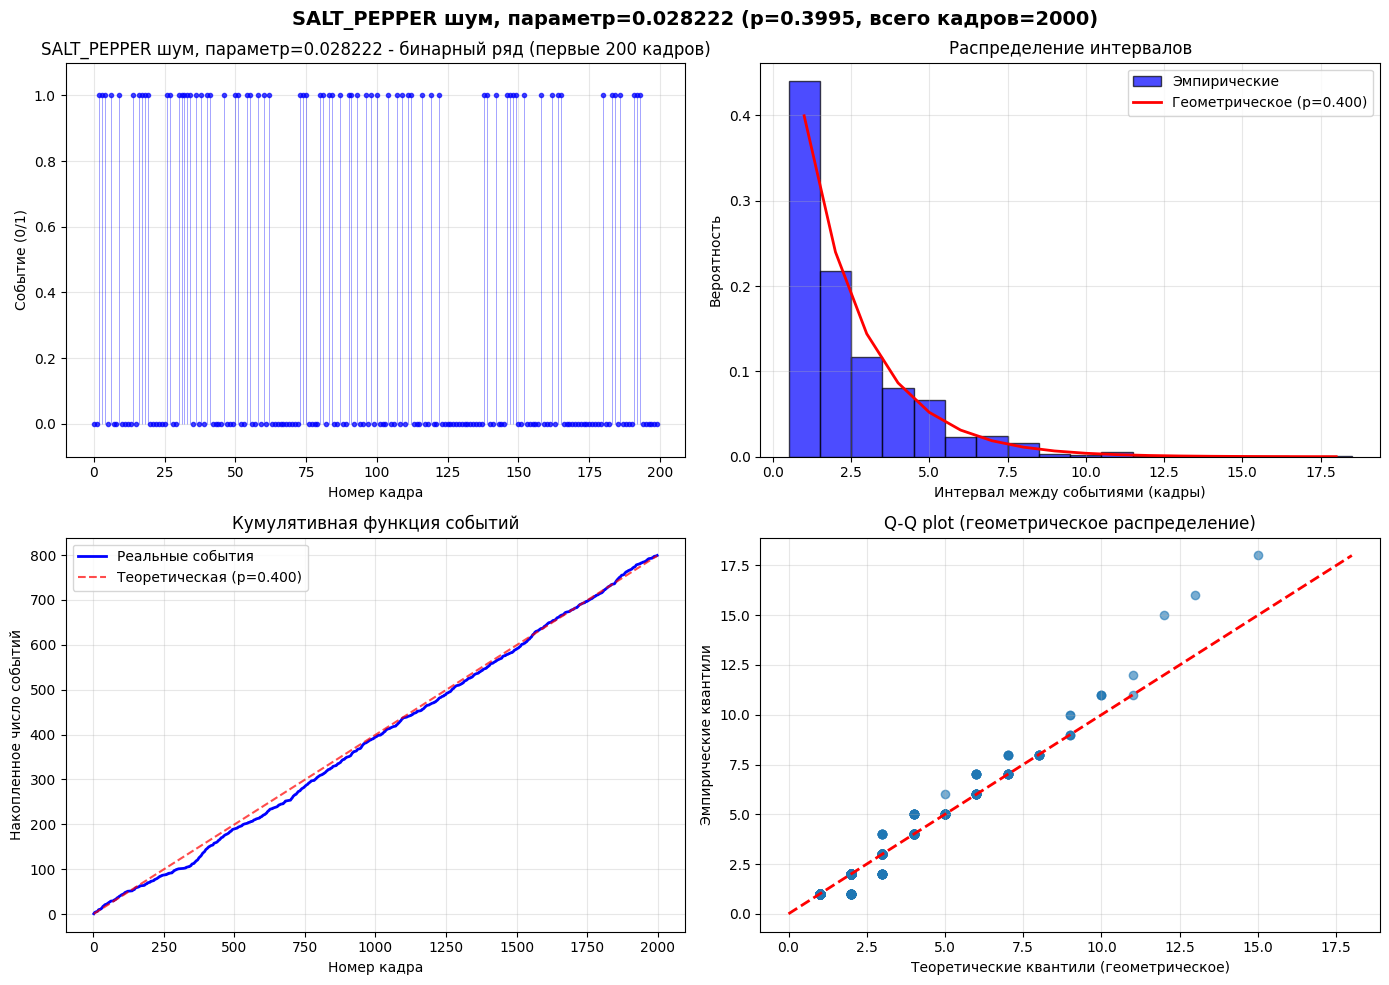


=== Проверка свойств процесса Бернулли для SALT_PEPPER шум, параметр=0.050000 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=19.2039, p-value=0.0377
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.8682
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: -0.0073
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 1.8485
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


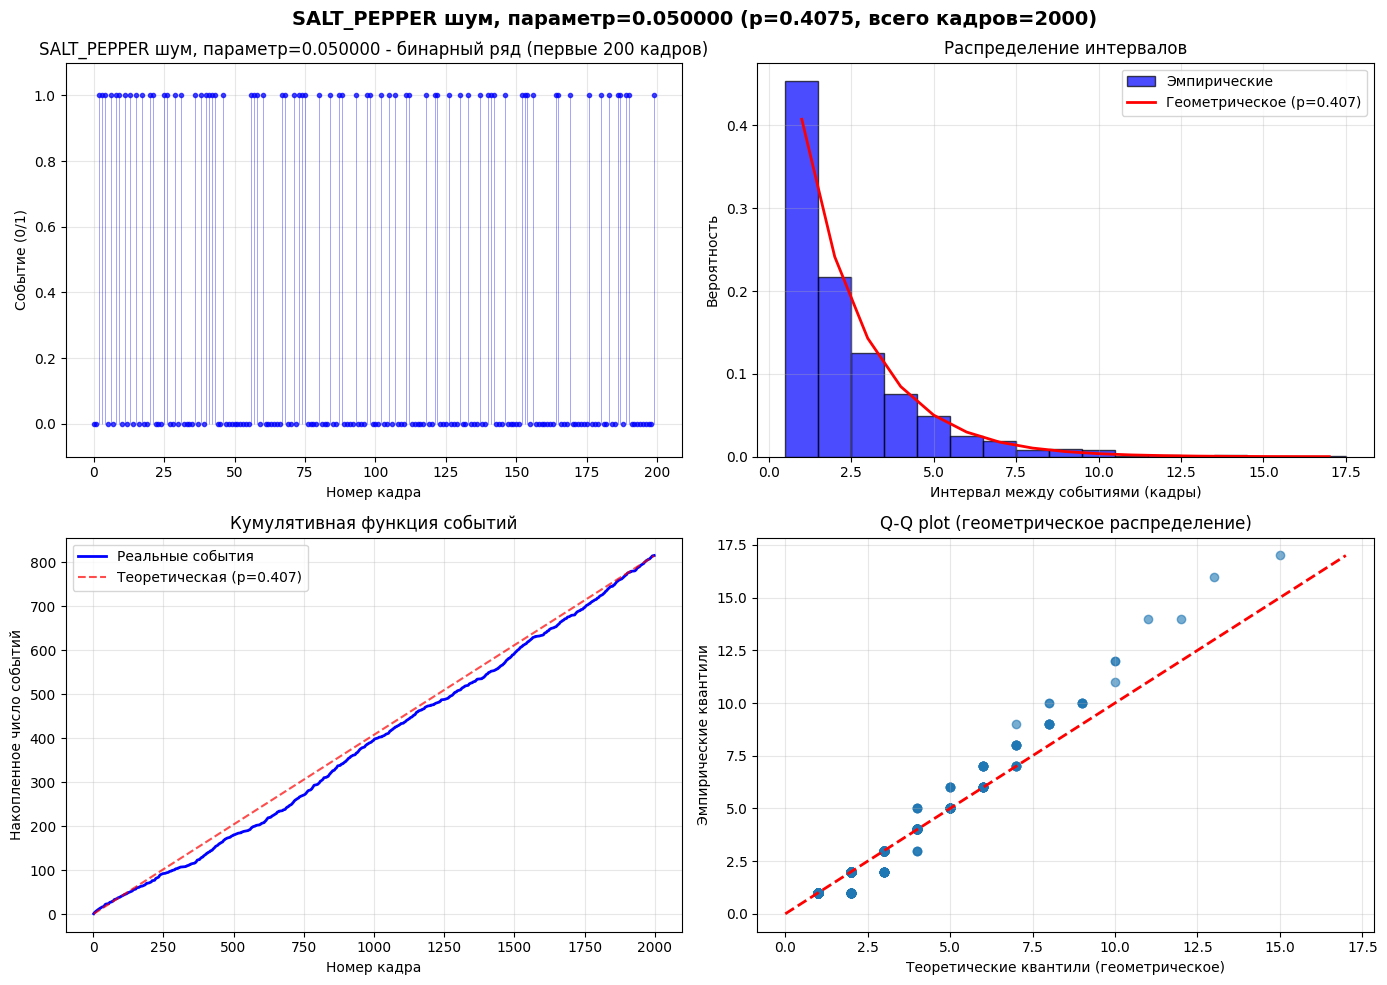


=== Проверка свойств процесса Бернулли для SPECKLE шум, параметр=0.050000 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=34.8191, p-value=0.0001
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.8306
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0456
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 1.5563
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


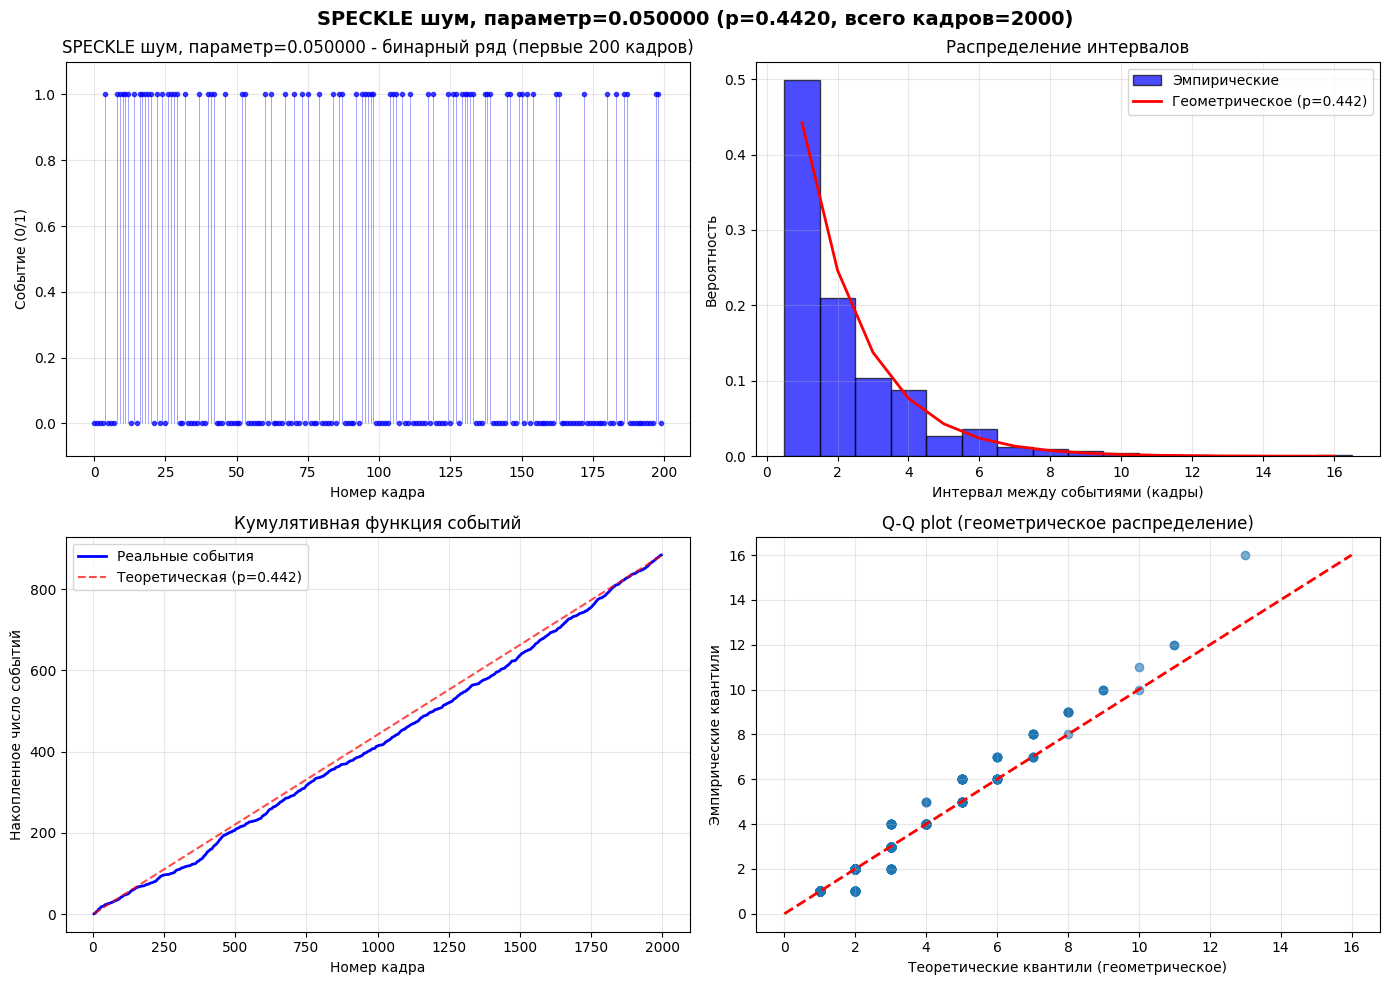


=== Проверка свойств процесса Бернулли для SPECKLE шум, параметр=0.459091 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=15.2373, p-value=0.1236
    ✓ Интервалы соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.8024
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: -0.0373
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 1.6166
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


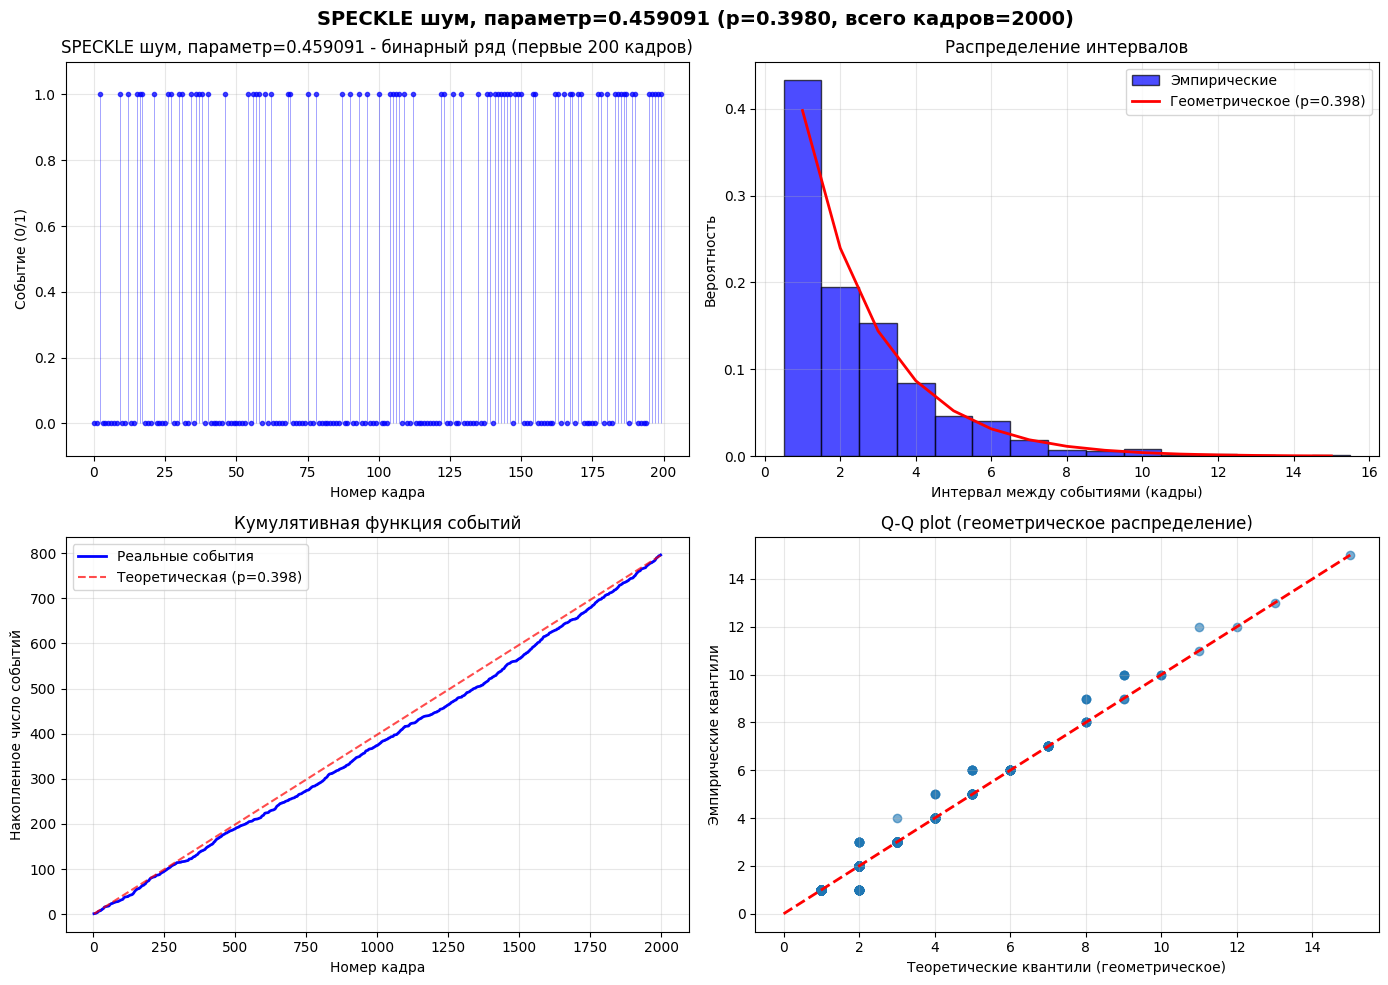


=== Проверка свойств процесса Бернулли для SPECKLE шум, параметр=0.800000 ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=23.5163, p-value=0.0090
    ✗ Интервалы НЕ соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.9191
    ✓ CV близок к 1 (соответствует геометрическому распределению)

  Автокорреляция интервалов: 0.0576
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 2.2630
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


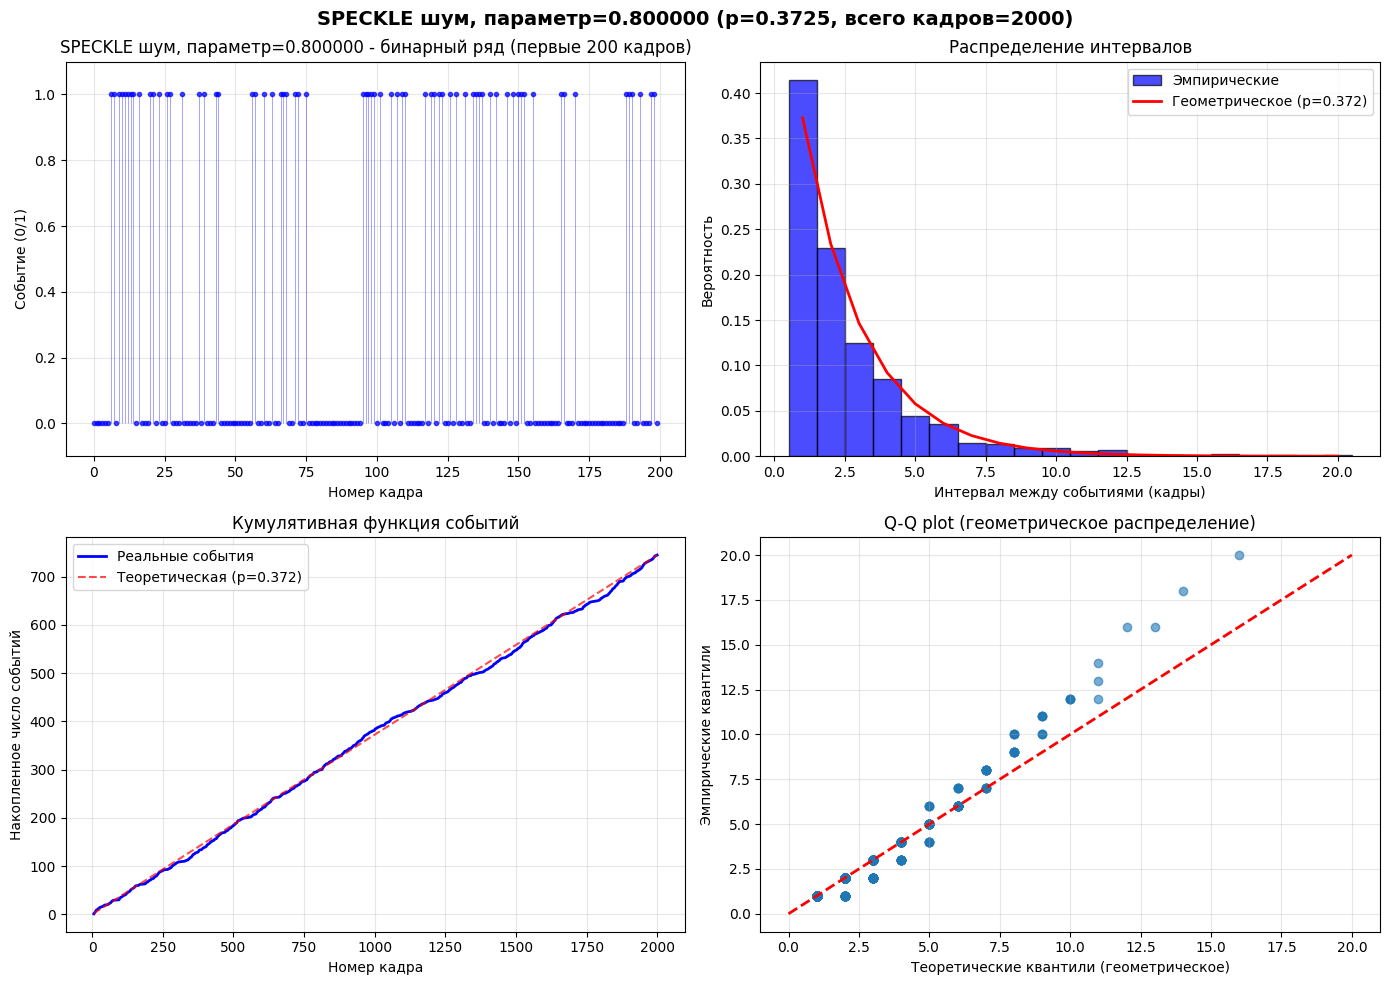

In [ ]:
# Выбираем для каждого типа шума минимальный, средний и максимальный параметр
# (там, где есть данные и достаточно событий)

for noise_name, data in assumptions_summary.items():
    # Отфильтруем записи с достаточно большим числом событий (>=5)
    valid = [d for d in data if not np.isnan(d["p"]) and d["n_events"] >= 5]
    if len(valid) == 0:
        continue
    params_sorted = sorted(valid, key=lambda x: x["param"])
    # Берём min, median, max (если есть хотя бы 3)
    selected = []
    if len(params_sorted) >= 3:
        selected.append(params_sorted[0])        # min
        selected.append(params_sorted[len(params_sorted)//2]) # median
        selected.append(params_sorted[-1])       # max
    elif len(params_sorted) == 2:
        selected = params_sorted
    elif len(params_sorted) == 1:
        selected = params_sorted
    
    for rec in selected:
        param = rec["param"]
        # Загружаем соответствующий файл, чтобы получить event_frames
        # (проще перезагрузить, но можно было сохранить ранее – для ясности)
        pattern = noise_types[noise_name]["pattern"].replace(r"([0-9.]+)", f"{param:.6f}")
        # Ищем файл с точным параметром (несколько знаков)
        files = list(results_dir.glob(f"{noise_name}_*.npy"))
        target_file = None
        for f in files:
            match = re.search(noise_types[noise_name]["pattern"], f.name)
            if match and abs(float(match.group(1)) - param) < 1e-6:
                target_file = f
                break
        if target_file is None:
            continue
        counts = np.load(target_file)
        event_frames = extract_event_frames(counts, threshold=EVENT_THRESHOLD)
        if len(event_frames) < 2:
            continue
        title = f"{noise_name.upper()} шум, параметр={param:.6f}"
        test_bernoulli_assumptions(event_frames, total_frames, title=title)
        visualize_bernoulli_process(event_frames, total_frames, title=title)